In [6]:
import os
from pypdf import PdfReader

# تحديد مسار مجلد المستندات
DOCS_DIR = os.path.join("..", "data", "documents")

# قراءة وفحص ملفات الـ PDF
documents_data = []

if os.path.exists(DOCS_DIR):
    pdf_files = [f for f in os.listdir(DOCS_DIR) if f.endswith(".pdf")]
    print(f"Total PDF files found: {len(pdf_files)}")

    for file_name in pdf_files:
        file_path = os.path.join(DOCS_DIR, file_name)
        reader = PdfReader(file_path)
        total_pages = len(reader.pages)

        # تجميع النص من كل الصفحات
        full_text = ""
        for page_num, page in enumerate(reader.pages):
            text = page.extract_text()
            if text:
                full_text += text + "\n"

        documents_data.append({
            "filename": file_name,
            "pages": total_pages,
            "text_length": len(full_text),
            "content": full_text
        })
        print(f" - Processed '{file_name}': {total_pages} pages, {len(full_text)} characters extracted.")
else:
    print(f"Directory {DOCS_DIR} not found. Please create it and add your PDFs.")

Total PDF files found: 1
 - Processed 'MICROCONTROLLERBOOK.pdf': 250 pages, 362871 characters extracted.


In [9]:
import chromadb
from sentence_transformers import SentenceTransformer

# 1. إستراتيجية تقطيع النصوص (Chunking Strategy)
CHUNK_SIZE = 1000   # عدد الحروف في كل قطعة
OVERLAP = 200       # عدد الحروف المشتركة بين القطع المتتالية للحفاظ على السياق

chunks = []

for doc in documents_data:
    text = doc["content"]
    filename = doc["filename"]

    start = 0
    chunk_id = 0
    while start < len(text):
        end = start + CHUNK_SIZE
        chunk_text = text[start:end]

        chunks.append({
            "id": f"{filename}_chunk_{chunk_id}",
            "text": chunk_text,
            "metadata": {
                "source": filename,
                "chunk_id": chunk_id
            }
        })
        start += (CHUNK_SIZE - OVERLAP)
        chunk_id += 1

print(f"Total chunks created: {len(chunks)}")

# 2. تحميل موديل الـ Embeddings
print("Loading Embedding Model...")
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

# 3. إنشاء وتحفيظ قاعدة البيانات ChromaDB
PERSIST_DIR = "../backend/data/vector_store"
chroma_client = chromadb.PersistentClient(path=PERSIST_DIR)

# إنشاء Collection جديد
collection = chroma_client.get_or_create_collection(name="pdf_documents")

print("Generating embeddings and adding to ChromaDB...")

# إضافة البيانات على دفعات (Batches) لضمان السرعة
batch_size = 500
for i in range(0, len(chunks), batch_size):
    batch = chunks[i:i + batch_size]

    batch_ids = [c["id"] for c in batch]
    batch_texts = [c["text"] for c in batch]
    batch_metadatas = [c["metadata"] for c in batch]

    # حساب الـ Embeddings
    batch_embeddings = embedding_model.encode(batch_texts).tolist()

    # الإضافة لقاعدة البيانات
    collection.add(
        ids=batch_ids,
        documents=batch_texts,
        metadatas=batch_metadatas,
        embeddings=batch_embeddings
    )
    print(f"Added batch {i // batch_size + 1} / {(len(chunks) - 1) // batch_size + 1}")

print("Vector Database created and persisted successfully!")

C:\Users\Administrator\PycharmProjects\PythonProject\rag-assistant-project\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Total chunks created: 454
Loading Embedding Model...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 21088.22it/s]


Generating embeddings and adding to ChromaDB...
Added batch 1 / 1
Vector Database created and persisted successfully!


In [11]:
# 1. تجربة استعلام/سؤال عن المتحكمات
query = "What is a microcontroller and how does it differ from a microprocessor?"

# 2. تحويل السؤال لـ Embedding
query_embedding = embedding_model.encode([query]).tolist()

# 3. البحث في ChromaDB عن أفضل 3 قطع مناسبة (top_k = 3)
results = collection.query(
    query_embeddings=query_embedding,
    n_results=3
)

# 4. طباعة النتائج المسترجعة
print(f"🔍 Question: {query}\n")
print("=" * 50)

for i, doc in enumerate(results["documents"][0]):
    metadata = results["metadatas"][0][i]  # تعديل الـ index إلى i
    print(f"\n--- Result {i+1} (Source: {metadata['source']}, Chunk ID: {metadata['chunk_id']}) ---")
    print(doc)

🔍 Question: What is a microcontroller and how does it differ from a microprocessor?


--- Result 1 (Source: MICROCONTROLLERBOOK.pdf, Chunk ID: 81) ---
 Code Snippets ................................................................................. 248 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
CHAPTER 1 
INTRODUCTION TO MICROCONTROLLERS 
 
 
Microcontrollers form the backbone of modern embedded systems. From smartphones 
and automobiles to washing machines and medical instruments, microcontrollers serve as 
the intelligent control unit that connects hardware and software to perform dedicated tasks 
efficiently. They are compact, cost -effective, and energy -efficient computing devices 
optimized for control-oriented operations. 
1.1 What is a Microcontroller 
A microcontroller (MCU) is a compact, single-chip computing device designed to control 
specific electronic applications. Unlike general-purpose computers or laptops, which can 
perform multiple tasks simultaneously, a microcont

In [19]:
from groq import Groq

# 1. إدخال الـ API Key الخاص بك من console.groq.com
client = Groq(api_key="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")

# 2. تجهيز السياق والسؤال
retrieved_chunks = results["documents"][0]
context_text = "\n\n---\n\n".join(retrieved_chunks)

system_prompt = """You are a helpful technical assistant.
Answer the user's question using ONLY the provided context below.
If the answer is not mentioned in the context, say 'I cannot find the answer in the provided document.' Do not guess."""

user_prompt = f"Context:\n{context_text}\n\nQuestion: {query}"

# 3. استخدام نموذج llama3 المتاح دائماً
response = client.chat.completions.create(
    model="openai/gpt-oss-20b",  # تم التعديل إلى موديل llama3 الشغال تماماً
    messages=[
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_prompt}
    ]
)

# 4. طباعة الإجابة
print("💡 Answer:\n")
print(response.choices[0].message.content)

💡 Answer:

A microcontroller (MCU) is a compact, single‑chip computing device that is specifically designed to control a particular electronic application. It contains everything needed for device control – a CPU, memory (RAM for temporary data and Flash/ROM for the program), and peripheral interfaces (GPIO, timers, serial ports such as UART, SPI, I²C) – all integrated on one silicon chip. The MCU runs a dedicated program that reads sensor data, processes it according to pre‑programmed logic, and drives actuators or communication devices.

**Key differences between a microcontroller and a microprocessor:**

| Feature | Microcontroller (MCU) | Microprocessor (MPU) |
|---------|-----------------------|----------------------|
| Integration | CPU, memory, and peripherals all on a single chip | Only the CPU; external RAM, ROM, and I/O devices are required |
| Typical use | Real‑time embedded control tasks (automation, robotics, smart appliances) | High‑speed general‑purpose computation, run

In [22]:
import os
from ultralytics import YOLO

# 1. تحميل نموذج YOLOv8 المسبق (YOLOv8n للحجم الخفيف والسرعة)
print("Loading YOLOv8 model...")
model = YOLO("../yolov8n.pt")  # سيقوم بتنزيل الأوزان تلقائياً عند التشغيل الأول

# 2. تحديد مسار صورة الاختبار
IMAGE_PATH = "../data/images/test_component.jpg"

if os.path.exists(IMAGE_PATH):
    # 3. تشغيل الكشف على الصورة
    results = model(IMAGE_PATH)

    # 4. استخراج الكائنات المكتشفة (Detected Labels)
    detected_objects = []
    for result in results:
        for box in result.boxes:
            class_id = int(box.cls[0])
            label = model.names[class_id]
            confidence = float(box.conf[0])
            detected_objects.append((label, confidence))
            print(f"🎯 Detected: {label} (Confidence: {confidence:.2f})")

    if not detected_objects:
        print("No specific components detected with high confidence.")
else:
    print(f"⚠️ Image not found at {IMAGE_PATH}. Please add an image to test.")

Loading YOLOv8 model...

image 1/1 C:\Users\Administrator\PycharmProjects\PythonProject\rag-assistant-project\notebooks\..\data\images\test_component.jpg: 640x640 1 cell phone, 36.0ms
Speed: 3.6ms preprocess, 36.0ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)
🎯 Detected: cell phone (Confidence: 0.43)


In [25]:
import os
from ultralytics import YOLO
from groq import Groq

# 1. تشغيل YOLO على الصورة
model = YOLO("../yolov8n.pt")
IMAGE_PATH = "../data/images/test_component.jpg"

results = model(IMAGE_PATH)
detected_label = results[0].names[int(results[0].boxes.cls[0])] if len(results[0].boxes) > 0 else "unknown"

print(f"Vision Model Raw Label: {detected_label}")

# 2. تحديد الكائن المستهدف للبحث (توجيه الاستعلام للقطعة الإلكترونية ESP32)
search_query = "ESP32 microcontroller specs, pins, and features"
print(f"Searching Vector Store for: '{search_query}'...\n")

# 3. استرجاع السياق من ChromaDB
query_emb = embedding_model.encode([search_query]).tolist()
rag_results = collection.query(query_embeddings=query_emb, n_results=2)
retrieved_context = "\n\n".join(rag_results["documents"][0])

# 4. توليد الإجابة النهائية عبر Groq API
client = Groq(api_key="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")

prompt = f"""You are an expert embedded systems assistant.
A user uploaded an image of an electronic development board identified as ESP32.

Use the following documentation context to provide a concise summary of its key features and pinout specs:
{retrieved_context}
"""

response = client.chat.completions.create(
    model="openai/gpt-oss-20b",
    messages=[{"role": "user", "content": prompt}]
)

print("Final Multimodal RAG Response:\n")
print(response.choices[0].message.content)


image 1/1 C:\Users\Administrator\PycharmProjects\PythonProject\rag-assistant-project\notebooks\..\data\images\test_component.jpg: 640x640 1 cell phone, 23.5ms
Speed: 2.2ms preprocess, 23.5ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 640)
Vision Model Raw Label: cell phone
Searching Vector Store for: 'ESP32 microcontroller specs, pins, and features'...

Final Multimodal RAG Response:

**ESP32 Development Board – Quick‑Start Reference**

| Feature | What It Means | Why It Matters |
|---------|---------------|----------------|
| **Dual‑core Xtensa LX6 (≤240 MHz)** | 2× 32‑bit CPUs | Parallel processing, lower latency for real‑time tasks |
| **Built‑in 802.11b/g/n Wi‑Fi** | 2.4 GHz radio | Seamless IoT connectivity without an external module |
| **Bluetooth 4.2 / BLE** | Classic BT + low‑energy | Proximity sensing, BLE‑sensor stacks, firmware updates |
| **36× Multi‑function GPIO (GPIO0–GPIO39)** | Digital I/O, ADC, DAC, PWM, touch | Flexible I/O for sensors, actuators, 

In [32]:
!pip install roboflow --no-deps
!pip install certifi chardet idna requests urllib3 python-dateutil cycler kiwisolver pyparsing six

from roboflow import Roboflow

rf = Roboflow(api_key="kRHbU17T3Irt95XzHOJj")
project = rf.workspace("charles-dominique-bacanto-sk3id").project("arduino-ugn9a")
version = project.version(5)
dataset = version.download("yolov8")



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Arduino-5 in yolov8:: 100%|██████████| 4212/4212 [00:01<00:00, 2575.53it/s]


In [35]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121 --force-reinstall

Looking in indexes: https://download.pytorch.org/whl/cu121
     ---------------------------------------- 0.0/2.4 GB ? eta -:--:--
     ---------------------------------------- 0.0/2.4 GB ? eta -:--:--
     ---------------------------------------- 0.0/2.4 GB ? eta -:--:--
     ---------------------------------------- 0.0/2.4 GB 1.3 MB/s eta 0:31:37
     ---------------------------------------- 0.0/2.4 GB 1.2 MB/s eta 0:34:01
     ---------------------------------------- 0.0/2.4 GB 1.2 MB/s eta 0:34:53
     ---------------------------------------- 0.0/2.4 GB 1.2 MB/s eta 0:34:53
     ---------------------------------------- 0.0/2.4 GB 1.1 MB/s eta 0:37:05
     ---------------------------------------- 0.0/2.4 GB 1.1 MB/s eta 0:37:55
     ---------------------------------------- 0.0/2.4 GB 1.1 MB/s eta 0:37:17
     ---------------------------------------- 0.0/2.4 GB 1.1 MB/s eta 0:35:46
     ---------------------------------------- 0.0/2.4 GB 1.1 MB/s eta 0:35:33
     ---------------------

  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
roboflow 1.5.0 requires opencv-python-headless>=4.10.0, which is not installed.
roboflow 1.5.0 requires typer<0.26,>=0.12.0, but you have typer 0.27.2 which is incompatible.

[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import torch

print("Torch Version:", torch.__version__)
print("CUDA Available:", torch.cuda.is_available())

Torch Version: 2.5.1+cu121
CUDA Available: True


In [4]:
from ultralytics import YOLO

# 1. تحميل الأوزان الأولية للنموذج الخفيف YOLOv8 Nano
model = YOLO("../yolov8n.pt")

# 2. بدء عملية التدريب باستخدام المعالج i7 القوي
results = model.train(
    data="Arduino-5/data.yaml",  # مسار الـ Dataset التي تم تنزيلها[span_0](start_span)[span_0](end_span)
    epochs=25,                   # عدد الدورات التدريبية
    imgsz=640,                   # أبعاد الصور
    device="cpu",                # الاعتماد على الـ CPU
    workers=16,                   # استخدام 8 نويات لتسريع نقل البيانات
    name="yolo_arduino_model"    # اسم مجلد حفظ نتائج التدريب
)

print("\n🎉 اكتمل التدريب بنجاح!")
print("مسار ملف الأوزان الجديد (best.pt):")
print("yolo_trained_model/detect/yolo_arduino_model/weights/best.pt")

Ultralytics 8.4.157  Python-3.10.11 torch-2.5.1+cu121 CPU (Intel Core i7-14700HX)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=Arduino-5/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo_arduino_model-2, nbs=64, nms=None, opset=None, opti

In [4]:
from ultralytics import YOLO

# 1. تحميل الأوزان المدربة الجديدة
model_path = "yolo_trained_model/best.pt"
model = YOLO(model_path)

# 2. إجراء التنبؤ مع إجبار التشغيل على الـ CPU
results = model.predict(
    source="Arduino-5/test/images",  # مسار صور الاختبار
    save=True,                       # حفظ الصور الموضحة بالمربعات
    conf=0.25,                       # حد الثقة
    device="cpu"                     # التشغيل المباشر على الـ CPU
)

print("🎯 تم الكشف عن المكونات بنجاح!")


image 1/47 C:\Users\Administrator\PycharmProjects\PythonProject\rag-assistant-project\notebooks\Arduino-5\test\images\23_jpg.rf.b473cc76f61e4a77f0f4345f2096a896.jpg: 640x640 2 Transistors, 64.6ms
image 2/47 C:\Users\Administrator\PycharmProjects\PythonProject\rag-assistant-project\notebooks\Arduino-5\test\images\45_jpg.rf.d87e0f8cb09daf8c61481327f11401d4.jpg: 640x640 2 Transistors, 37.7ms
image 3/47 C:\Users\Administrator\PycharmProjects\PythonProject\rag-assistant-project\notebooks\Arduino-5\test\images\53_jpg.rf.fec3a9a8feb67f27e7cfe9379ca129f6.jpg: 640x640 2 Transistors, 36.0ms
image 4/47 C:\Users\Administrator\PycharmProjects\PythonProject\rag-assistant-project\notebooks\Arduino-5\test\images\60_jpg.rf.57ef2db199adc3cf5026dc82d764869d.jpg: 640x640 2 Transistors, 33.9ms
image 5/47 C:\Users\Administrator\PycharmProjects\PythonProject\rag-assistant-project\notebooks\Arduino-5\test\images\72_jpg.rf.2ffb61c671c3673d2e25ced9b3e65e4e.jpg: 640x640 2 Transistors, 42.7ms
image 6/47 C:\Users

📸 عرض النتيجة للصورة: runs/detect/predict-2\23_jpg.rf.b473cc76f61e4a77f0f4345f2096a896.jpg


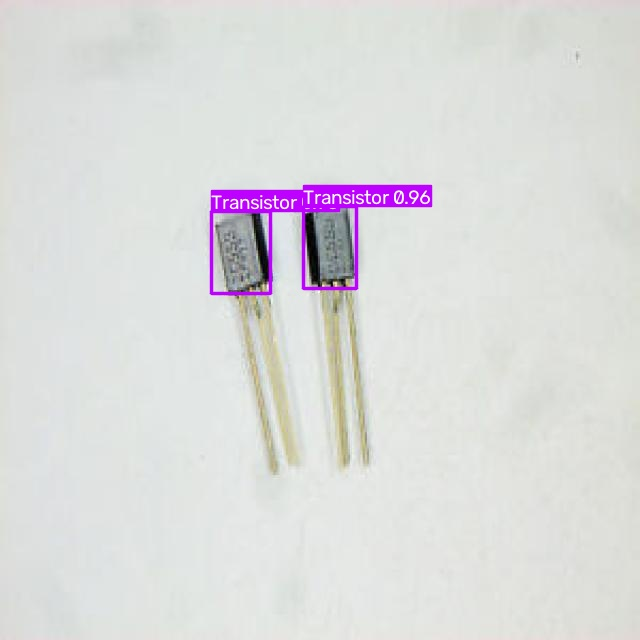

🎯 Mapped Component for RAG: Transistor (Confidence: 95.61%)
🎯 Mapped Component for RAG: Transistor (Confidence: 94.86%)


In [5]:
import glob
from IPython.display import Image, display

# 1. عرض صورة من الصور التي تم الكشف عليها وتحديد المكونات فيها
output_images = glob.glob("../data/predict-2/*.jpg")

if output_images:
    print(f"📸 عرض النتيجة للصورة: {output_images[0]}")
    display(Image(filename=output_images[0]))

# 2. كود استخراج أسماء المكونات لاستخدامها لاحقاً في الـ RAG
for result in results[:1]: # اختبرنا أول صورة
    boxes = result.boxes
    for box in boxes:
        class_id = int(box.cls[0])
        class_name = model.names[class_id]
        confidence = float(box.conf[0])
        print(f"🎯 Mapped Component for RAG: {class_name} (Confidence: {confidence:.2%})")

In [6]:
# استخراج المكونات المكتشفة وتمريرها لنظام الـ RAG
detected_components = []

for result in results:
    for box in result.boxes:
        class_id = int(box.cls[0])
        class_name = model.names[class_id]
        confidence = float(box.conf[0])

        # حفظ المكون إذا كانت نسبة الثقة أعلى من 50%
        if confidence > 0.50:
            detected_components.append(class_name)

# إزالة التكرار مع الحفاظ على القائمة
query_components = list(set(detected_components))

# بناء الاستعلام القادم لنظام الـ RAG
rag_query = f"Provide detailed specifications, pin configuration, and usage guidelines for: {', '.join(query_components)}"

print("📝 RAG Prompt Generated:")
print(rag_query)

📝 RAG Prompt Generated:
Provide detailed specifications, pin configuration, and usage guidelines for: Arduino, Transistor, Integrated Circuit, Jumper-Wires, Resistor


In [7]:
import os
import chromadb

# 1. تحديد المسار الصحيح للـ Chroma Vector Store من داخل مجلد notebooks
CHROMA_PATH = "../backend/data/vector_store"

# 2. الاتصال بـ ChromaDB
client = chromadb.PersistentClient(path=CHROMA_PATH)

# الحصول على الـ Collections المتاحة
collections = client.list_collections()
print("📁 Available Collections:", [c.name for c in collections])

# اختيار المجموعة الأولى
collection_name = collections[0].name if collections else "langchain"
collection = client.get_collection(name=collection_name)

# 3. الاستعلام عن المكونات المكتشفة من YOLO
retrieved_context = []

for component in query_components:
    print(f"🔍 Searching ChromaDB for: {component}...")
    results = collection.query(
        query_texts=[component],
        n_results=2
    )

    if results and 'documents' in results and results['documents']:
        for doc_list in results['documents']:
            retrieved_context.extend(doc_list)

# 4. دمج النص المسترجع
context_text = "\n\n--- Document Excerpt ---\n".join(retrieved_context)

# 5. صياغة الـ RAG Prompt النهائي الشامل
final_rag_prompt = f"""
You are an expert embedded systems assistant.
Use the provided technical context from documents to explain specifications and usage for: {', '.join(query_components)}.

--- Technical Context ---
{context_text}

--- User Query ---
{rag_query}
"""

print("\n🎉 Final RAG Prompt with Real Context Ready!")
print(final_rag_prompt[:1000]) # عرض أول 1000 حرف للتأكد من وجود النصوص

📁 Available Collections: ['pdf_documents', 'components_docs']
🔍 Searching ChromaDB for: Arduino...
🔍 Searching ChromaDB for: Transistor...
🔍 Searching ChromaDB for: Integrated Circuit...
🔍 Searching ChromaDB for: Jumper-Wires...
🔍 Searching ChromaDB for: Resistor...

🎉 Final RAG Prompt with Real Context Ready!

You are an expert embedded systems assistant.
Use the provided technical context from documents to explain specifications and usage for: Arduino, Transistor, Integrated Circuit, Jumper-Wires, Resistor.

--- Technical Context ---
 
 
 
MICROCONTROLLER 
 
 
 
 
 
 
 
 
 
 
 
By 
AADHITYA S.V 
 B.E 
 
 
 
 
 
 

Copyright © 2025 by Aadhitya S.V .   
 
All rights reserved. No part of this publication may be reproduced, stored in a retrieval 
system, or transmitted in any form or by any means —electronic, mechanical, 
photocopying, recording, or otherwise —without the prior written permission of the 
author/publisher, except for brief quotations in reviews or academic references.   
